### Load Required Packages

In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn import metrics
import matplotlib.pyplot as plt
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator

### Helper Functions

In [10]:
def extract_layer_output(model, layer_name, data):
    int_layer_op = model.get_layer(name=layer_name).output
    # Handle Sequential models loaded from file (model.input may not be set)
    try:
        int_layer_model = Model(inputs=model.input, outputs=int_layer_op)
    except AttributeError:
        int_layer_model = Model(inputs=model.layers[0].input, outputs=int_layer_op)
    int_layer_model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['acc'])
    return int_layer_model.predict(data)


In [11]:
def generate_df(arr, label):
    df = pd.DataFrame(arr)
    df['label'] = label
    return df

### Load Dataset

In [12]:
base_path = './combined-real-and-fake-faces/combined-real-vs-fake/'
image_gen = ImageDataGenerator(rescale=1./255.)

train_flow = image_gen.flow_from_directory(
    base_path + 'train/',
    target_size=(224, 224),
    batch_size=64,
    shuffle=False,
    class_mode='binary'
)

test_flow = image_gen.flow_from_directory(
    base_path + 'test/',
    target_size=(224, 224),
    batch_size=1,
    shuffle = False,
    class_mode='binary'
)

Found 100000 images belonging to 2 classes.
Found 20000 images belonging to 2 classes.


In [13]:
y_test = test_flow.classes

### Custom CNN Model Trained without Data Augmentation

In [14]:
custom_model = load_model('./models/custom_model.h5')

**Extract Intermediate Layer to get vector representation of the images**

In [15]:
int_output_custom = extract_layer_output(custom_model, 'global_average_pooling2d', train_flow)
int_output_custom.shape

c:\Users\Amey Ravindra Pandit\OneDrive\Desktop\2b Projet\deepfake-image-detection\.venv39\lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


c:\Users\Amey Ravindra Pandit\OneDrive\Desktop\2b Projet\deepfake-image-detection\.venv39\lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


1563/1563 ━━━━━━━━━━━━━━━━━━━━ 2061s 1s/step


c:\Users\Amey Ravindra Pandit\OneDrive\Desktop\2b Projet\deepfake-image-detection\.venv39\lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


1563/1563 ━━━━━━━━━━━━━━━━━━━━ 2061s 1s/step


(100000, 512)

In [16]:
int_output_custom = generate_df(int_output_custom, train_flow.classes)
int_output_custom.head()

,0,1,2,3,4,5,6,7,8,9,...,503,504,505,506,507,508,509,510,511,label
0,0.269413,-0.402127,-0.272527,0.381295,-0.062962,-0.015933,-0.671447,0.403579,-0.146744,-0.153247,...,-0.113021,0.105043,-0.075374,-0.300424,0.045774,0.318291,-0.127774,-0.240098,-0.206313,0
1,-0.774279,-1.083222,0.640564,0.981943,-0.762646,0.240792,-0.601545,0.057443,-0.115083,-0.858218,...,-0.384982,-0.570209,0.456106,-0.265096,0.376147,0.464824,-0.284069,-0.830716,-0.053630,0
2,-0.162900,-0.572969,-0.252710,0.402982,0.126442,-0.056214,-0.287031,0.435247,0.785121,-0.503514,...,-0.011697,0.222454,0.169272,-0.492176,-0.032269,0.224592,-0.052101,-0.376113,-0.063783,0
3,-0.397418,-0.242587,0.631149,0.680116,-0.485413,0.851097,-0.135448,-0.441873,-0.345924,0.008367,...,-0.238575,0.330773,-0.353189,-0.616576,-0.446976,-0.187403,-0.089124,-0.214658,0.041762,0
4,-0.307038,-0.260856,0.709478,0.410272,-0.897964,0.450029,-0.591033,0.033682,0.656076,-0.322102,...,-0.493027,0.741182,0.374123,-0.627545,-0.014887,0.187385,0.436721,-0.442132,0.851466,0


In [17]:
int_output_custom.tail()

,0,1,2,3,4,5,6,7,8,9,...,503,504,505,506,507,508,509,510,511,label
99995,0.093154,-0.241751,-0.196264,0.103165,-0.201044,0.233954,-0.209285,0.034889,0.093043,0.506435,...,-0.027555,-0.115419,-0.600593,-0.438710,0.463627,-0.552545,0.099643,-0.503626,-0.118332,1
99996,0.876788,0.162104,-0.692476,-0.810859,-0.316844,0.093142,0.239730,-0.632535,-0.260612,-0.150343,...,-0.450736,-0.378088,-0.367510,0.016275,-0.095025,0.835277,0.023558,0.481392,-0.536421,1
99997,-0.139308,-0.368598,0.298656,0.331689,-0.622738,0.244496,-0.522207,-0.597718,-0.137675,-0.353571,...,-0.266153,-0.230518,-0.222718,-0.302008,-0.357410,-0.159433,0.328157,-0.256016,-0.008371,1
99998,-0.424731,-0.619283,0.925907,0.264867,0.282256,-0.167158,-0.884744,0.362673,-0.103765,0.216894,...,-0.026963,0.237145,-0.808231,0.179788,1.036633,-0.819960,-0.222275,-0.733827,0.367857,1
99999,-0.665872,-0.197917,0.462535,0.562706,0.323362,0.409649,0.055798,-0.165837,-0.513721,-0.466713,...,-0.533245,0.429808,0.007751,-0.246977,0.082875,-0.138026,0.291495,-0.650477,0.417972,1


In [18]:
int_output_custom.to_csv('./custom_model_rep.csv', index=False)

**Predictions**

In [19]:
y_pred_custom = custom_model.predict(test_flow)

c:\Users\Amey Ravindra Pandit\OneDrive\Desktop\2b Projet\deepfake-image-detection\.venv39\lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


c:\Users\Amey Ravindra Pandit\OneDrive\Desktop\2b Projet\deepfake-image-detection\.venv39\lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


20000/20000 ━━━━━━━━━━━━━━━━━━━━ 434s 22ms/step


**Evaluation Report**

In [20]:
print("ROC AUC Score:", metrics.roc_auc_score(y_test, y_pred_custom))
print("AP Score:", metrics.average_precision_score(y_test, y_pred_custom))
print()
print(metrics.classification_report(y_test, y_pred_custom > 0.5))

ROC AUC Score: 0.98463804
AP Score: 0.9840132831571669

              precision    recall  f1-score   support

           0       0.79      0.99      0.88     10000
           1       0.99      0.74      0.84     10000

    accuracy                           0.86     20000
   macro avg       0.89      0.86      0.86     20000
weighted avg       0.89      0.86      0.86     20000



___
### Custom CNN Model Trained with Data Augmentation

In [21]:
custom_aug_model = load_model('./models/custom_augmented_model.h5')

**Extract Intermediate Layer to get vector representation of the images**

In [23]:
int_output_cus_aug = extract_layer_output(custom_aug_model, 'global_average_pooling2d', train_flow)
int_output_cus_aug.shape

1563/1563 ━━━━━━━━━━━━━━━━━━━━ 579s 370ms/step


1563/1563 ━━━━━━━━━━━━━━━━━━━━ 579s 370ms/step


(100000, 512)

In [24]:
int_output_cus_aug = generate_df(int_output_cus_aug, train_flow.classes)
int_output_cus_aug.head()

,0,1,2,3,4,5,6,7,8,9,...,503,504,505,506,507,508,509,510,511,label
0,0.165535,0.277984,0.598057,-0.041591,0.460393,0.057214,-0.002335,-0.605699,-0.146184,0.879724,...,0.196288,0.449372,-0.312163,-0.122808,0.191978,-0.295371,0.514868,0.848886,0.183507,0
1,0.221291,-0.415254,-0.147366,-0.226094,-0.729362,-0.088293,1.244956,-0.377148,1.038518,0.144434,...,-1.012589,-0.103069,-0.342766,-1.019106,-0.300593,-0.883787,-0.589998,-0.515869,-0.330062,0
2,0.275328,-0.066160,-0.010362,-0.262707,-0.206418,-0.218938,0.954196,-0.372670,1.164547,0.176592,...,-0.390006,-0.079856,0.062809,0.107509,-0.021370,-0.673562,0.034449,0.435486,0.454974,0
3,-0.598914,0.274890,-0.197151,0.626241,-0.201061,0.061178,1.089920,0.024634,1.201255,0.024246,...,-0.458026,0.236605,-0.555537,-0.081611,0.040845,-0.471109,0.032230,-0.057069,-0.158442,0
4,-0.452860,-0.010265,0.920122,0.587589,-0.204882,-0.447895,-0.360981,-0.629911,0.397713,-0.257371,...,-0.398444,0.190427,-0.644897,-0.307113,-0.173862,0.410680,-0.097158,-0.354206,0.772746,0


In [25]:
int_output_cus_aug.tail()

,0,1,2,3,4,5,6,7,8,9,...,503,504,505,506,507,508,509,510,511,label
99995,0.017862,-0.280118,0.061110,0.493898,0.395239,0.404828,0.130676,-0.514074,-0.764526,0.252510,...,0.169120,-0.043094,0.465298,-0.450087,0.067153,0.153468,-0.089957,0.992705,0.715861,1
99996,0.229146,1.063639,-0.781906,0.125377,1.500909,0.753213,0.967737,-0.556578,-1.102921,0.144305,...,0.785983,0.322902,-0.133238,0.334814,0.094191,-0.017164,1.010508,0.908300,0.074974,1
99997,-0.189096,-0.491415,0.289207,-0.048210,-0.059590,0.110267,-0.062867,-0.389585,0.199619,-0.142316,...,-0.336153,-0.315977,-0.382898,-0.137132,0.332032,0.541501,-0.305563,-0.092437,0.258910,1
99998,-0.037978,-0.346881,-0.174803,0.045621,0.733937,-0.609111,-0.234043,0.345628,-0.585884,0.644159,...,-0.501385,0.002486,-0.407262,-0.149906,0.076864,0.410428,-0.189055,0.352563,0.828890,1
99999,-0.758669,-0.050580,0.161289,0.940794,-0.383299,-1.018163,-0.373618,0.317069,1.228987,-0.442450,...,-1.014295,-0.200198,-0.753903,0.039482,-0.884133,0.058222,-0.769152,-0.310021,0.601720,1


In [26]:
int_output_cus_aug.to_csv('./custom_augmented_model_rep.csv', index=False)

**Predictions**

In [27]:
y_pred_cus_agg = custom_aug_model.predict(test_flow)

20000/20000 ━━━━━━━━━━━━━━━━━━━━ 248s 12ms/step


**Evaluation Report**

In [28]:
print("ROC AUC Score:", metrics.roc_auc_score(y_test, y_pred_cus_agg))
print("AP Score:", metrics.average_precision_score(y_test, y_pred_cus_agg))
print()
print(metrics.classification_report(y_test, y_pred_cus_agg > 0.5))

ROC AUC Score: 0.93731811
AP Score: 0.9326614947087929

              precision    recall  f1-score   support

           0       0.65      0.98      0.78     10000
           1       0.96      0.47      0.63     10000

    accuracy                           0.73     20000
   macro avg       0.81      0.73      0.71     20000
weighted avg       0.81      0.73      0.71     20000



___
### VGGFace Fine Tuned Model without Data Augmentation

In [6]:
vggface = load_model('./models/vggface_v1.h5')

**Extract Intermediate Layer to get vector representation of the images**

In [9]:
int_output_vgg = extract_layer_output(vggface, 'fc1', train_flow)
int_output_vgg.shape

(100000, 2048)

In [10]:
int_output_vgg = generate_df(int_output_vgg, train_flow.classes)
int_output_vgg.head()

,0,1,2,3,4,5,6,7,8,9,...,2039,2040,2041,2042,2043,2044,2045,2046,2047,label
0,0.0,0.847519,0.724391,0.0,0.0,1.018900,0.0,0.0,0.0,0.592672,...,0.594139,0.0,0.874365,0.0,0.730746,0.0,0.0,0.0,0.0,0
1,0.0,1.504278,1.343664,0.0,0.0,1.875045,0.0,0.0,0.0,1.099996,...,1.133855,0.0,1.619812,0.0,1.195965,0.0,0.0,0.0,0.0,0
2,0.0,1.414378,1.264059,0.0,0.0,1.752962,0.0,0.0,0.0,1.079500,...,1.105139,0.0,1.558315,0.0,1.165056,0.0,0.0,0.0,0.0,0
3,0.0,0.820791,0.721580,0.0,0.0,1.061604,0.0,0.0,0.0,0.570302,...,0.631258,0.0,0.839116,0.0,0.655513,0.0,0.0,0.0,0.0,0
4,0.0,1.089702,0.941631,0.0,0.0,1.313845,0.0,0.0,0.0,0.764574,...,0.774959,0.0,1.141736,0.0,0.919725,0.0,0.0,0.0,0.0,0


In [11]:
int_output_vgg.tail()

,0,1,2,3,4,5,6,7,8,9,...,2039,2040,2041,2042,2043,2044,2045,2046,2047,label
99995,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.134997,0.0,0.0,0.0,0.0,0.0,0.437865,0.0,1
99996,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.469873,0.0,0.0,0.0,0.0,0.0,0.699707,0.0,1
99997,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.289712,0.0,0.0,0.0,0.0,0.0,0.501795,0.0,1
99998,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.159435,0.0,0.0,0.0,0.0,0.0,0.424813,0.0,1
99999,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.285008,0.0,1


In [12]:
int_output_vgg.to_csv('./vggface_rep.csv', index=False)

**Predictions**

In [13]:
y_pred_vgg = vggface.predict(test_flow)

**Evaluation Report**

In [14]:
print("ROC AUC Score:", metrics.roc_auc_score(y_test, y_pred_vgg))
print("AP Score:", metrics.average_precision_score(y_test, y_pred_vgg))
print()
print(metrics.classification_report(y_test, y_pred_vgg > 0.5))

ROC AUC Score: 0.9600932210254477
AP Score: 0.9325796549056171

              precision    recall  f1-score   support

           0       0.97      0.92      0.94     10735
           1       0.93      0.97      0.95     10856

    accuracy                           0.95     21591
   macro avg       0.95      0.95      0.95     21591
weighted avg       0.95      0.95      0.95     21591



___
### DenseNet Model Trained without Data Augmentation

In [15]:
densenet_v1 = load_model('./models/densenet_v1.h5')

**Extract Intermediate Layer to get vector representation of the images**

In [16]:
int_output_dv1 = extract_layer_output(densenet_v1, 'global_average_pooling2d', train_flow)
int_output_dv1.shape

(100000, 1024)

In [17]:
int_output_dv1 = generate_df(int_output_dv1, train_flow.classes)
int_output_dv1.head()

,0,1,2,3,4,5,6,7,8,9,...,1015,1016,1017,1018,1019,1020,1021,1022,1023,label
0,0.280332,0.071319,0.290553,0.340185,0.522443,0.664085,0.501311,0.319497,0.418953,0.619749,...,0.517286,0.200696,0.549189,0.502353,0.347513,0.522260,0.155741,0.162449,0.288870,0
1,0.183173,0.082026,0.221390,0.335868,0.412098,0.557626,0.392902,0.319508,0.260044,0.514430,...,0.443096,0.184226,0.484547,0.439558,0.296033,0.510709,0.146062,0.307765,0.282705,0
2,0.306966,0.028815,0.208510,0.338645,0.380179,0.512343,0.371461,0.284346,0.558514,0.460414,...,0.343907,0.125783,0.373969,0.345774,0.312796,0.371904,0.071682,0.141716,0.196437,0
3,0.164646,0.053577,0.138079,0.182050,0.269746,0.357534,0.267633,0.154713,0.306458,0.323547,...,0.164306,0.030136,0.173777,0.166105,0.174043,0.182507,0.003204,0.097136,0.067782,0
4,0.274487,0.047566,0.233368,0.312017,0.440843,0.567504,0.430719,0.298505,0.526158,0.527211,...,0.464798,0.179264,0.475700,0.446901,0.421227,0.426989,0.138764,0.274363,0.257648,0


In [18]:
int_output_dv1.tail()

,0,1,2,3,4,5,6,7,8,9,...,1015,1016,1017,1018,1019,1020,1021,1022,1023,label
99995,0.247740,0.048858,0.034092,0.156509,0.092039,0.098219,0.093814,0.073495,0.418897,0.070975,...,0.006717,0.000000,0.005063,0.001984,0.142422,0.004966,0.000000,0.091542,0.000000,1
99996,0.166594,0.085349,0.007205,0.126247,0.031711,0.028504,0.021576,0.047941,0.260957,0.013486,...,0.000730,0.000000,0.000000,0.000000,0.176630,0.000000,0.000000,0.110408,0.000000,1
99997,0.245655,0.050536,0.000000,0.236500,0.000000,0.002336,0.000149,0.091581,0.326663,0.000000,...,0.021405,0.017917,0.023024,0.021247,0.470571,0.053040,0.104478,0.535990,0.032849,1
99998,0.194670,0.051522,0.013928,0.181728,0.032735,0.037647,0.036570,0.100740,0.317533,0.026759,...,0.000000,0.000000,0.000000,0.000000,0.201610,0.002224,0.000000,0.209803,0.000000,1
99999,0.237341,0.030115,0.027945,0.239910,0.071306,0.099464,0.073482,0.181533,0.390559,0.092659,...,0.049324,0.003451,0.051871,0.044997,0.199534,0.042105,0.006861,0.237598,0.003288,1


In [19]:
int_output_dv1.to_csv('./densenet_v1_rep.csv', index=False)

**Predictions**

In [20]:
y_pred_dv1 = densenet_v1.predict(test_flow)

**Evaluation Report**

In [21]:
print("ROC AUC Score:", metrics.roc_auc_score(y_test, y_pred_dv1))
print("AP Score:", metrics.average_precision_score(y_test, y_pred_dv1))
print()
print(metrics.classification_report(y_test, y_pred_dv1 > 0.5))

ROC AUC Score: 0.9565295476644934
AP Score: 0.9201108482795977

              precision    recall  f1-score   support

           0       0.96      0.91      0.93     10735
           1       0.92      0.96      0.94     10856

    accuracy                           0.94     21591
   macro avg       0.94      0.93      0.94     21591
weighted avg       0.94      0.94      0.94     21591



___
### DenseNet Model Trained with Data Augmentation

In [22]:
densenet_v2 = load_model('./models/completed_augmented_trained_model.h5')

In [23]:
int_output_dv2 = extract_layer_output(densenet_v2, 'global_average_pooling2d', train_flow)
int_output_dv2.shape

(100000, 1024)

In [24]:
int_output_dv2 = generate_df(int_output_dv2, train_flow.classes)
int_output_dv2.head()

,0,1,2,3,4,5,6,7,8,9,...,1015,1016,1017,1018,1019,1020,1021,1022,1023,label
0,0.007733,0.308077,0.179216,0.226038,0.011687,0.033950,0.068752,0.012405,0.017951,0.006271,...,0.138699,0.139463,0.034762,0.012312,0.032738,0.042244,0.070153,0.040713,0.000000,0
1,0.000000,0.172728,0.137209,0.251077,0.022890,0.079947,0.028373,0.053193,0.089327,0.010746,...,0.005464,0.004107,0.097207,0.000000,0.115579,0.107559,0.121534,0.113003,0.000000,0
2,0.173725,0.234279,0.130502,0.102781,0.176708,0.200163,0.103589,0.045222,0.078049,0.118724,...,0.000000,0.000000,0.525753,0.000000,0.505240,0.461878,0.522006,0.546764,0.000872,0
3,0.001673,0.087842,0.134919,0.146676,0.050943,0.081155,0.058619,0.034621,0.121339,0.007844,...,0.123320,0.130635,0.011787,0.016820,0.017439,0.012898,0.038882,0.012645,0.000000,0
4,0.349492,0.119816,0.090997,0.101662,0.372251,0.375042,0.086264,0.097567,0.244376,0.306474,...,0.188555,0.176222,0.010226,0.022402,0.009612,0.014992,0.045365,0.012990,0.000000,0


In [25]:
int_output_dv2.tail()

,0,1,2,3,4,5,6,7,8,9,...,1015,1016,1017,1018,1019,1020,1021,1022,1023,label
99995,0.007817,0.056224,0.140868,0.178844,0.035814,0.067317,0.053892,0.045024,0.050506,0.003240,...,0.339615,0.365875,0.000000,0.051119,0.000006,0.001524,0.004344,0.000000,0.0,1
99996,0.015979,0.308204,0.085681,0.167717,0.051222,0.035701,0.075214,0.076101,0.142398,0.008909,...,0.278237,0.275099,0.007384,0.039792,0.007786,0.013853,0.019550,0.008079,0.0,1
99997,0.000032,0.116553,0.057942,0.129742,0.026495,0.015593,0.058353,0.007719,0.207266,0.002220,...,0.564847,0.572360,0.000000,0.079895,0.000000,0.000000,0.000549,0.000000,0.0,1
99998,0.000000,0.102807,0.077523,0.156468,0.021161,0.055570,0.056154,0.050333,0.158036,0.013285,...,0.438286,0.461540,0.000000,0.057126,0.000000,0.000000,0.000000,0.000000,0.0,1
99999,0.000000,0.063047,0.131515,0.155310,0.128023,0.123048,0.043221,0.096711,0.155520,0.006480,...,0.095271,0.103567,0.004075,0.006800,0.001699,0.007196,0.025675,0.006080,0.0,1


In [26]:
int_output_dv2.to_csv('./augmented_densenet_rep.csv', index=False)

**Predictions**

In [27]:
y_pred_dv2 = densenet_v2.predict(test_flow)

**Evaluation Report**

In [28]:
print("ROC AUC Score:", metrics.roc_auc_score(y_test, y_pred_dv2))
print("AP Score:", metrics.average_precision_score(y_test, y_pred_dv2))
print()
print(metrics.classification_report(y_test, y_pred_dv2 > 0.5))

ROC AUC Score: 0.8713568040133463
AP Score: 0.8531290555629062

              precision    recall  f1-score   support

           0       0.92      0.50      0.65     10735
           1       0.66      0.95      0.78     10856

    accuracy                           0.73     21591
   macro avg       0.79      0.73      0.71     21591
weighted avg       0.79      0.73      0.72     21591



___
### DenseNet Model Trained on GrayScale Images

In [29]:
## update train flow and test flow to use grayscale color mode
gs_train_flow = image_gen.flow_from_directory(
    base_path + 'train/',
    target_size=(224, 224),
    batch_size=64,
    color_mode='grayscale',
    class_mode='binary'
)

gs_test_flow = image_gen.flow_from_directory(
    base_path + 'test/',
    target_size=(224, 224),
    batch_size=1,
    color_mode='grayscale',
    shuffle = False,
    class_mode='binary'
)

gs_ytest = gs_test_flow.classes

Found 100000 images belonging to 2 classes.
Found 21591 images belonging to 2 classes.


In [30]:
densenet_v3 = load_model('./models/grayscale_densenet.h5')

In [31]:
int_output_dv3 = extract_layer_output(densenet_v3, 'global_average_pooling2d', gs_train_flow)
int_output_dv3.shape

(100000, 1024)

In [32]:
int_output_dv3 = generate_df(int_output_dv3, gs_train_flow.classes)
int_output_dv3.head()

,0,1,2,3,4,5,6,7,8,9,...,1015,1016,1017,1018,1019,1020,1021,1022,1023,label
0,0.414529,0.175976,0.095803,0.310555,0.322692,0.380952,0.444872,0.054188,0.453329,0.244413,...,0.679426,0.894111,0.675123,0.908890,0.007420,0.043818,0.019302,0.070596,0.913934,0
1,0.370391,0.211070,0.060519,0.184226,0.225421,0.251126,0.403371,0.033979,0.287812,0.147493,...,0.470601,0.645039,0.468310,0.689303,0.000430,0.035568,0.011910,0.021756,0.706609,0
2,0.141266,0.227677,0.075993,0.137283,0.321078,0.154649,0.406908,0.039503,0.201645,0.199975,...,0.071512,0.112266,0.069054,0.107850,0.000000,0.648311,0.752640,0.000000,0.108715,0
3,0.382479,0.144771,0.067355,0.300038,0.276331,0.404183,0.499999,0.013849,0.473038,0.215729,...,0.843818,1.143932,0.839693,1.108382,0.027453,0.022176,0.000000,0.116104,1.129797,0
4,0.367230,0.165550,0.062561,0.268029,0.219110,0.336069,0.413858,0.028105,0.377839,0.222069,...,0.586386,0.786428,0.585640,0.780634,0.000963,0.042635,0.013581,0.058412,0.798584,0


In [33]:
int_output_dv3.tail()

,0,1,2,3,4,5,6,7,8,9,...,1015,1016,1017,1018,1019,1020,1021,1022,1023,label
99995,0.192754,0.251515,0.076746,0.243519,0.178318,0.218602,0.273818,0.021992,0.261691,0.099795,...,0.195096,0.299754,0.189364,0.275339,0.000000,0.026833,0.018347,0.000914,0.277786,1
99996,0.348302,0.196883,0.075690,0.258971,0.299307,0.364393,0.397140,0.039209,0.402618,0.230673,...,0.620962,0.795964,0.625078,0.831531,0.001088,0.039773,0.001530,0.055240,0.836867,1
99997,0.150589,0.145887,0.070173,0.076549,0.202291,0.110434,0.378214,0.015665,0.156470,0.199457,...,0.060364,0.095530,0.053732,0.130559,0.000000,0.476348,0.540662,0.000000,0.139037,1
99998,0.168436,0.217703,0.045867,0.200744,0.204450,0.176166,0.378975,0.046548,0.236584,0.243044,...,0.219617,0.311769,0.224463,0.352476,0.000000,0.060311,0.032675,0.000299,0.364894,1
99999,0.141163,0.170443,0.049447,0.119694,0.257018,0.093513,0.402462,0.025809,0.146966,0.236763,...,0.016196,0.038116,0.015373,0.035102,0.000000,0.553219,0.598571,0.000000,0.049867,1


In [34]:
int_output_dv3.to_csv('./grayscale_densenet_rep.csv', index=False)

**Predictions**

In [35]:
y_pred_dv3 = densenet_v3.predict(gs_test_flow)

**Evaluation Report**

In [36]:
print("ROC AUC Score:", metrics.roc_auc_score(gs_ytest, y_pred_dv3))
print("AP Score:", metrics.average_precision_score(gs_ytest, y_pred_dv3))
print()
print(metrics.classification_report(gs_ytest, y_pred_dv3 > 0.5))

ROC AUC Score: 0.9594158735999128
AP Score: 0.9224849866162643

              precision    recall  f1-score   support

           0       0.99      0.90      0.94     10735
           1       0.91      0.99      0.95     10856

    accuracy                           0.94     21591
   macro avg       0.95      0.94      0.94     21591
weighted avg       0.95      0.94      0.94     21591



___
### Comparison

In [64]:
cus_fpr, cus_tpr, _ = metrics.roc_curve(y_test, y_pred_custom)
cus_roc_auc = metrics.auc(cus_fpr, cus_tpr)

cus_agg_fpr, cus_agg_tpr, _ = metrics.roc_curve(y_test, y_pred_cus_agg)
cus_agg_roc_auc = metrics.auc(cus_agg_fpr, cus_agg_tpr)

vgg_fpr, vgg_tpr, _ = metrics.roc_curve(y_test, y_pred_vgg)
vgg_roc_auc = metrics.auc(vgg_fpr, vgg_tpr)

dv1_fpr, dv1_tpr, _ = metrics.roc_curve(y_test, y_pred_dv1)
dv1_roc_auc = metrics.auc(dv1_fpr, dv1_tpr)

dv2_fpr, dv2_tpr, _ = metrics.roc_curve(y_test, y_pred_dv2)
dv2_roc_auc = metrics.auc(dv2_fpr, dv2_tpr)

dv3_fpr, dv3_tpr, _ = metrics.roc_curve(gs_ytest, y_pred_dv3)
dv3_roc_auc = metrics.auc(dv3_fpr, dv3_tpr)

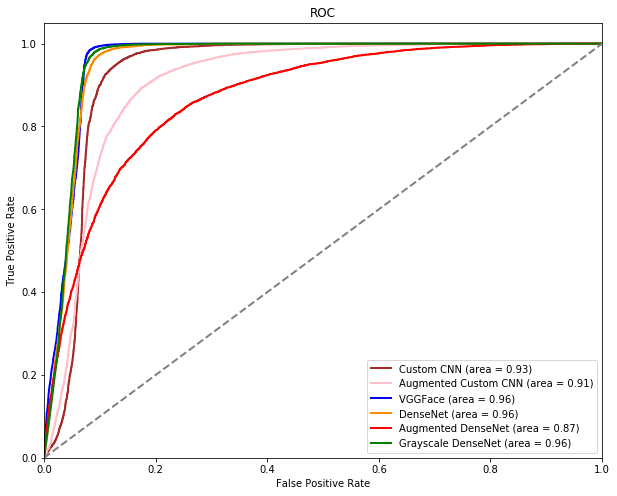

In [65]:
plt.figure(figsize=(10,8))
lw = 2
plt.plot(cus_fpr, cus_tpr, color='brown', lw=lw, label='Custom CNN (area = %0.2f)' % cus_roc_auc)
plt.plot(cus_agg_fpr, cus_agg_tpr, color='pink', lw=lw, label='Augmented Custom CNN (area = %0.2f)' % cus_agg_roc_auc)
plt.plot(vgg_fpr, vgg_tpr, color='blue', lw=lw, label='VGGFace (area = %0.2f)' % vgg_roc_auc)
plt.plot(dv1_fpr, dv1_tpr, color='darkorange', lw=lw, label='DenseNet (area = %0.2f)' % dv1_roc_auc)
plt.plot(dv2_fpr, dv2_tpr, color='red', lw=lw, label='Augmented DenseNet (area = %0.2f)' % dv2_roc_auc)
plt.plot(dv3_fpr, dv3_tpr, color='green', lw=lw, label='Grayscale DenseNet (area = %0.2f)' % dv3_roc_auc)
plt.plot([0, 1], [0, 1], color='gray', lw=lw, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC')
plt.legend(loc="lower right")
plt.show()

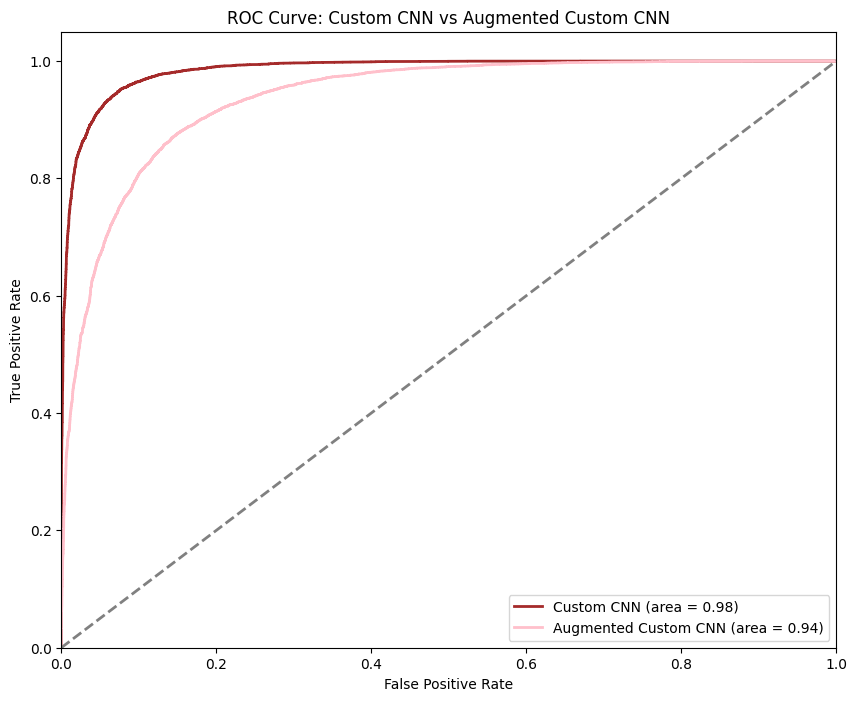

In [30]:
# ROC Curve for only available models (Custom CNN and Augmented Custom CNN)
from sklearn import metrics
cus_fpr, cus_tpr, _ = metrics.roc_curve(y_test, y_pred_custom)
cus_roc_auc = metrics.auc(cus_fpr, cus_tpr)

cus_agg_fpr, cus_agg_tpr, _ = metrics.roc_curve(y_test, y_pred_cus_agg)
cus_agg_roc_auc = metrics.auc(cus_agg_fpr, cus_agg_tpr)

plt.figure(figsize=(10,8))
lw = 2
plt.plot(cus_fpr, cus_tpr, color='brown', lw=lw, label='Custom CNN (area = %0.2f)' % cus_roc_auc)
plt.plot(cus_agg_fpr, cus_agg_tpr, color='pink', lw=lw, label='Augmented Custom CNN (area = %0.2f)' % cus_agg_roc_auc)
plt.plot([0, 1], [0, 1], color='gray', lw=lw, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve: Custom CNN vs Augmented Custom CNN')
plt.legend(loc="lower right")
plt.show()